In [1]:
import os
import json
import time
import random
import tracemalloc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
PyTorch: 2.13.0+cpu


In [3]:
data_file = "quantum_encoded_healthcare_data.xlsx"

quantum_model_file = (
    "optimized_variational_quantum_model.pt"
)

optimization_file = (
    "quantum_circuit_optimization_results.xlsx"
)

noise_file = (
    "quantum_noise_simulation_results.xlsx"
)

output_file = (
    "quantum_model_analysis_benchmarking.xlsx"
)

configuration_file = (
    "quantum_model_benchmarking_config.json"
)

required_files = [
    data_file,
    quantum_model_file,
    optimization_file,
    noise_file
]

for file_name in required_files:
    if not os.path.exists(file_name):
        raise FileNotFoundError(
            f"{file_name} was not found."
        )

print("All required files are available.")

All required files are available.


In [4]:
X_train_df = pd.read_excel(
    data_file,
    sheet_name="X_Train_Quantum"
)

X_test_df = pd.read_excel(
    data_file,
    sheet_name="X_Test_Quantum"
)

y_train_df = pd.read_excel(
    data_file,
    sheet_name="Y_Train"
)

y_test_df = pd.read_excel(
    data_file,
    sheet_name="Y_Test"
)

X_train = X_train_df.to_numpy(
    dtype=np.float32
)

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

y_train = y_train_df[
    "encoded_target"
].to_numpy(dtype=np.int64)

y_test = y_test_df[
    "encoded_target"
].to_numpy(dtype=np.int64)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 4)
Testing data: (100, 4)


In [5]:
try:
    checkpoint = torch.load(
        quantum_model_file,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        quantum_model_file,
        map_location="cpu"
    )

selected_circuit = checkpoint["circuit_name"]
selected_template = checkpoint["template"]
selected_layers = int(checkpoint["layers"])
n_qubits = int(checkpoint["n_qubits"])
n_classes = int(checkpoint["n_classes"])
weight_shapes = checkpoint["weight_shapes"]

print("Circuit:", selected_circuit)
print("Template:", selected_template)
print("Layers:", selected_layers)
print("Qubits:", n_qubits)
print("Classes:", n_classes)

Circuit: Basic_2_Layers
Template: basic
Layers: 2
Qubits: 4
Classes: 12


In [6]:
quantum_device = qml.device(
    "default.qubit",
    wires=n_qubits
)

wires = list(range(n_qubits))

@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def optimized_quantum_circuit(inputs, weights):
    qml.AngleEmbedding(
        features=inputs,
        wires=wires,
        rotation="Y"
    )

    if selected_template == "basic":
        qml.BasicEntanglerLayers(
            weights=weights,
            wires=wires,
            rotation=qml.RY
        )

    elif selected_template == "strong":
        qml.StronglyEntanglingLayers(
            weights=weights,
            wires=wires
        )

    else:
        raise ValueError(
            f"Unknown template: {selected_template}"
        )

    return [
        qml.expval(qml.PauliZ(wire))
        for wire in wires
    ]

In [7]:
class BenchmarkQuantumClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            optimized_quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            n_classes
        )

    def forward(self, inputs):
        quantum_features = self.quantum_layer(
            inputs
        )

        return self.output_layer(
            quantum_features
        )


quantum_model = BenchmarkQuantumClassifier()

quantum_model.load_state_dict(
    checkpoint["model_state_dict"]
)

quantum_model.eval()

print(quantum_model)

BenchmarkQuantumClassifier(
  (quantum_layer): <Quantum Torch Layer: func=optimized_quantum_circuit>
  (output_layer): Linear(in_features=4, out_features=12, bias=True)
)


In [8]:
parameter_rows = []

for parameter_name, parameter in (
    quantum_model.named_parameters()
):
    parameter_rows.append({
        "parameter": parameter_name,
        "shape": str(tuple(parameter.shape)),
        "parameter_count": parameter.numel(),
        "memory_bytes": (
            parameter.numel()
            * parameter.element_size()
        )
    })

parameter_details = pd.DataFrame(
    parameter_rows
)

quantum_parameter_count = int(
    np.prod(weight_shapes["weights"])
)

total_parameter_count = int(
    parameter_details[
        "parameter_count"
    ].sum()
)

parameter_memory_bytes = int(
    parameter_details[
        "memory_bytes"
    ].sum()
)

print("Quantum parameters:",
      quantum_parameter_count)

print("Total trainable parameters:",
      total_parameter_count)

print("Parameter memory:",
      parameter_memory_bytes, "bytes")

display(parameter_details)

Quantum parameters: 8
Total trainable parameters: 68
Parameter memory: 272 bytes


,parameter,shape,parameter_count,memory_bytes
0,quantum_layer.weights,"(2, 4)",8,32
1,output_layer.weight,"(12, 4)",48,192
2,output_layer.bias,"(12,)",12,48


In [9]:
example_input = torch.tensor(
    X_test[0],
    dtype=torch.float32
)

example_weights = torch.zeros(
    weight_shapes["weights"],
    dtype=torch.float32
)

circuit_gate_count = np.nan
circuit_depth = np.nan
gate_types = {}

try:
    circuit_specs = qml.specs(
        optimized_quantum_circuit,
        level="device"
    )(
        example_input,
        example_weights
    )

    circuit_resources = circuit_specs[
        "resources"
    ]

    circuit_gate_count = (
        circuit_resources.num_gates
    )

    circuit_depth = (
        circuit_resources.depth
    )

    gate_types = dict(
        circuit_resources.gate_types
    )

except Exception as error:
    print(
        "Detailed resource extraction was unavailable:",
        error
    )

circuit_analysis = pd.DataFrame({
    "property": [
        "Circuit name",
        "Template",
        "Qubits",
        "Variational layers",
        "Quantum parameters",
        "Total trainable parameters",
        "Gate count",
        "Circuit depth",
        "Gate types"
    ],
    "value": [
        selected_circuit,
        selected_template,
        n_qubits,
        selected_layers,
        quantum_parameter_count,
        total_parameter_count,
        circuit_gate_count,
        circuit_depth,
        str(gate_types)
    ]
})

display(circuit_analysis)

,property,value
0,Circuit name,Basic_2_Layers
1,Template,basic
2,Qubits,4
3,Variational layers,2
4,Quantum parameters,8
5,Total trainable parameters,68
6,Gate count,20
7,Circuit depth,11
8,Gate types,"{'RY': 12, 'CNOT': 8}"


In [10]:
def calculate_performance(
    model_name,
    targets,
    predictions,
    probabilities,
    training_seconds,
    inference_seconds
):
    accuracy = accuracy_score(
        targets,
        predictions
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            targets,
            predictions
        )
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            targets,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            targets,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    top_3_classes = np.argsort(
        probabilities,
        axis=1
    )[:, -3:]

    top_3_accuracy = np.mean([
        target in predicted_classes
        for target, predicted_classes
        in zip(targets, top_3_classes)
    ])

    throughput = (
        len(targets) / inference_seconds
        if inference_seconds > 0
        else np.nan
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "balanced_accuracy":
            balanced_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "top_3_accuracy": top_3_accuracy,
        "training_seconds":
            training_seconds,
        "inference_seconds":
            inference_seconds,
        "milliseconds_per_record": (
            inference_seconds
            / len(targets)
            * 1000
        ),
        "records_per_second":
            throughput
    }

In [11]:
X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

# Warm-up
with torch.no_grad():
    _ = quantum_model(
        X_test_tensor[:5]
    )

quantum_inference_times = []

for _ in range(10):
    start_time = time.perf_counter()

    with torch.no_grad():
        quantum_logits = quantum_model(
            X_test_tensor
        )

    quantum_inference_times.append(
        time.perf_counter() - start_time
    )

quantum_inference_seconds = float(
    np.median(quantum_inference_times)
)

with torch.no_grad():
    quantum_logits = quantum_model(
        X_test_tensor
    )

    quantum_probabilities = torch.softmax(
        quantum_logits,
        dim=1
    ).cpu().numpy()

quantum_predictions = np.argmax(
    quantum_probabilities,
    axis=1
)

print(
    "Median quantum inference time:",
    round(quantum_inference_seconds, 6),
    "seconds"
)

Median quantum inference time: 0.027282 seconds


In [12]:
optimization_history = pd.read_excel(
    optimization_file,
    sheet_name="Circuit_Comparison"
)

optimization_history.columns = (
    optimization_history.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

selected_training_row = (
    optimization_history[
        optimization_history[
            "circuit_name"
        ] == selected_circuit
    ]
)

if not selected_training_row.empty:
    quantum_training_seconds = float(
        selected_training_row[
            "training_seconds"
        ].iloc[0]
    )
else:
    quantum_training_seconds = np.nan

print(
    "Recorded optimization training time:",
    quantum_training_seconds
)

Recorded optimization training time: 9.361216306686401


In [13]:
classical_models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "RBF SVM":
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}

classical_benchmark_results = {}

In [14]:
benchmark_rows = []

quantum_performance = calculate_performance(
    model_name="Optimized Quantum Model",
    targets=y_test,
    predictions=quantum_predictions,
    probabilities=quantum_probabilities,
    training_seconds=quantum_training_seconds,
    inference_seconds=quantum_inference_seconds
)

benchmark_rows.append(
    quantum_performance
)

for model_name, classical_model in (
    classical_models.items()
):
    print("Benchmarking:", model_name)

    training_start = time.perf_counter()

    classical_model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )
    _ = classical_model.predict_proba(
        X_test[:5]
    )

    inference_times = []

    for _ in range(20):
        inference_start = time.perf_counter()

        probabilities = (
            classical_model.predict_proba(
                X_test
            )
        )

        inference_times.append(
            time.perf_counter()
            - inference_start
        )

    inference_seconds = float(
        np.median(inference_times)
    )

    probabilities = (
        classical_model.predict_proba(
            X_test
        )
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    classical_benchmark_results[
        model_name
    ] = {
        "model": classical_model,
        "probabilities": probabilities,
        "predictions": predictions
    }

    benchmark_rows.append(
        calculate_performance(
            model_name=model_name,
            targets=y_test,
            predictions=predictions,
            probabilities=probabilities,
            training_seconds=training_seconds,
            inference_seconds=inference_seconds
        )
    )

benchmark_results = pd.DataFrame(
    benchmark_rows
)

display(benchmark_results)

Benchmarking: Logistic Regression
Benchmarking: RBF SVM
Benchmarking: Random Forest


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,training_seconds,inference_seconds,milliseconds_per_record,records_per_second
0,Optimized Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,9.361216,0.027282,0.272820,3665.420423
1,Logistic Regression,0.25,0.252910,0.265717,0.252910,0.244439,0.243683,0.75,0.098995,0.000567,0.005667,176460.208070
2,RBF SVM,0.37,0.354034,0.373703,0.354034,0.313212,0.324331,0.78,0.100737,0.009859,0.098588,10143.273738
3,Random Forest,0.30,0.303142,0.287873,0.303142,0.291069,0.289654,0.74,1.382895,0.108849,1.088488,918.706003


In [15]:
quantum_file_size_bytes = os.path.getsize(
    quantum_model_file
)

model_size_rows = [{
    "model": "Optimized Quantum Model",
    "stored_model_size_bytes":
        quantum_file_size_bytes,
    "stored_model_size_kb":
        quantum_file_size_bytes / 1024,
    "trainable_parameters":
        total_parameter_count
}]

for model_name, result in (
    classical_benchmark_results.items()
):
    temporary_file = (
        f"temporary_{model_name.lower().replace(' ', '_')}.pkl"
    )

    import joblib

    joblib.dump(
        result["model"],
        temporary_file
    )

    file_size = os.path.getsize(
        temporary_file
    )

    model_size_rows.append({
        "model": model_name,
        "stored_model_size_bytes":
            file_size,
        "stored_model_size_kb":
            file_size / 1024,
        "trainable_parameters":
            np.nan
    })

    os.remove(temporary_file)

model_sizes = pd.DataFrame(
    model_size_rows
)

display(model_sizes)

,model,stored_model_size_bytes,stored_model_size_kb,trainable_parameters
0,Optimized Quantum Model,3485,3.403320,68.0
1,Logistic Regression,1175,1.147461,NaN
2,RBF SVM,88687,86.608398,NaN
3,Random Forest,7077113,6911.243164,NaN


In [16]:
batch_sizes = [
    1,
    4,
    8,
    16,
    32,
    64,
    len(X_test)
]

batch_rows = []

for batch_size in batch_sizes:
    actual_batch_size = min(
        batch_size,
        len(X_test)
    )

    batch_tensor = X_test_tensor[
        :actual_batch_size
    ]

    # Warm-up
    with torch.no_grad():
        _ = quantum_model(batch_tensor)

    timing_values = []

    for _ in range(10):
        start_time = time.perf_counter()

        with torch.no_grad():
            _ = quantum_model(
                batch_tensor
            )

        timing_values.append(
            time.perf_counter()
            - start_time
        )

    median_seconds = float(
        np.median(timing_values)
    )

    batch_rows.append({
        "requested_batch_size":
            batch_size,
        "actual_batch_size":
            actual_batch_size,
        "median_inference_seconds":
            median_seconds,
        "milliseconds_per_record": (
            median_seconds
            / actual_batch_size
            * 1000
        ),
        "records_per_second": (
            actual_batch_size
            / median_seconds
        )
    })

batch_scalability = pd.DataFrame(
    batch_rows
)

display(batch_scalability)

,requested_batch_size,actual_batch_size,median_inference_seconds,milliseconds_per_record,records_per_second
0,1,1,0.017563,17.563000,56.937881
1,4,4,0.019836,4.958950,201.655592
2,8,8,0.018374,2.296756,435.396660
3,16,16,0.018294,1.143347,874.625210
4,32,32,0.018138,0.566805,1764.276164
5,64,64,0.021768,0.340124,2940.102307
6,100,100,0.021724,0.217235,4603.309779


In [17]:
noise_metrics = pd.read_excel(
    noise_file,
    sheet_name="Noise_Metrics"
)

noise_metrics.columns = (
    noise_metrics.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

noise_only = noise_metrics[
    noise_metrics["noise_model"] != "none"
].copy()

noise_benchmark = (
    noise_only
    .groupby(
        "noise_model",
        as_index=False
    )
    .agg(
        average_accuracy=("accuracy", "mean"),
        minimum_accuracy=("accuracy", "min"),
        average_macro_f1=("macro_f1", "mean"),
        minimum_macro_f1=("macro_f1", "min"),
        average_prediction_stability=(
            "prediction_stability",
            "mean"
        ),
        minimum_prediction_stability=(
            "prediction_stability",
            "min"
        )
    )
)

display(noise_benchmark)

,noise_model,average_accuracy,minimum_accuracy,average_macro_f1,minimum_macro_f1,average_prediction_stability,minimum_prediction_stability
0,amplitude_damping,0.266,0.25,0.191836,0.170086,0.968,0.89
1,depolarizing,0.258,0.24,0.182981,0.155375,0.978,0.94
2,phase_damping,0.268,0.26,0.195866,0.187502,0.996,0.98


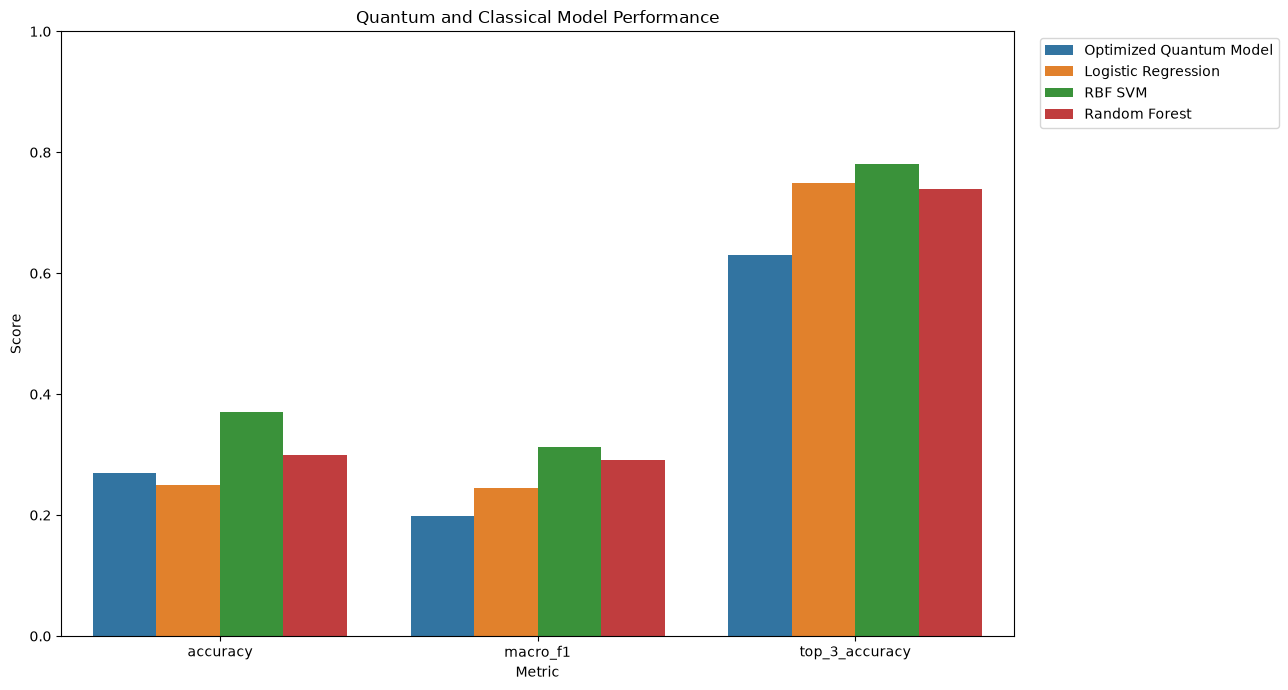

In [18]:
performance_long = (
    benchmark_results[
        [
            "model",
            "accuracy",
            "macro_f1",
            "top_3_accuracy"
        ]
    ]
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score"
    )
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=performance_long,
    x="metric",
    y="score",
    hue="model"
)

plt.ylim(0, 1)
plt.title(
    "Quantum and Classical Model Performance"
)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

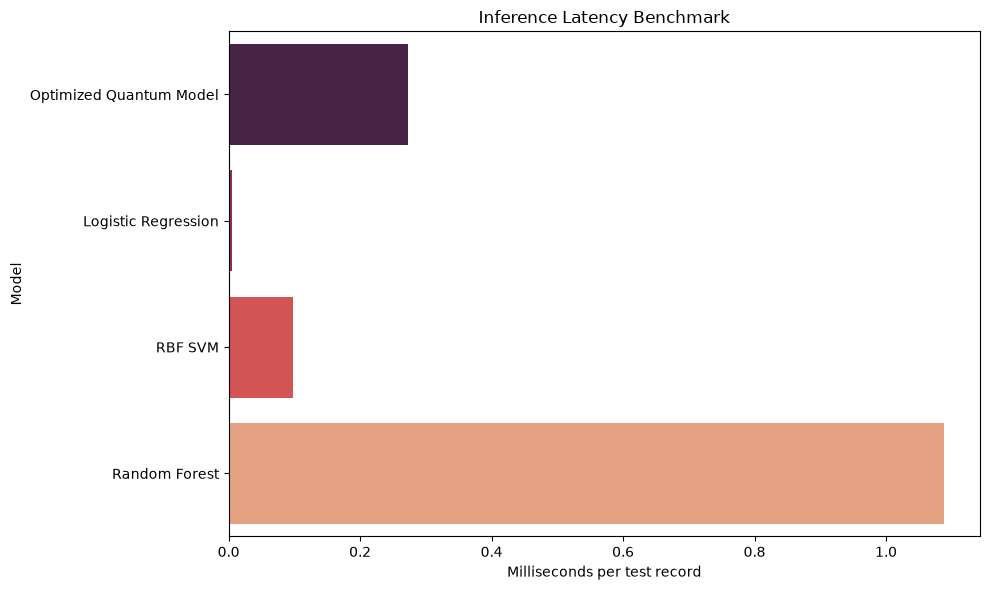

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=benchmark_results,
    x="milliseconds_per_record",
    y="model",
    hue="model",
    palette="rocket",
    legend=False
)

plt.title("Inference Latency Benchmark")
plt.xlabel("Milliseconds per test record")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

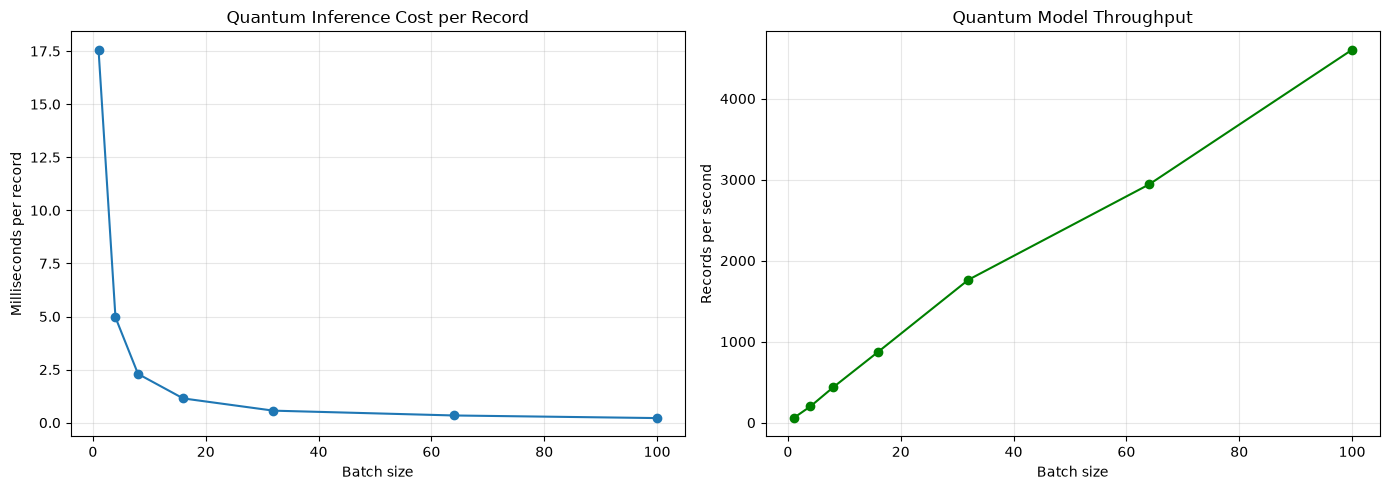

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    batch_scalability[
        "actual_batch_size"
    ],
    batch_scalability[
        "milliseconds_per_record"
    ],
    marker="o"
)

axes[0].set_title(
    "Quantum Inference Cost per Record"
)
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel(
    "Milliseconds per record"
)
axes[0].grid(alpha=0.3)

axes[1].plot(
    batch_scalability[
        "actual_batch_size"
    ],
    batch_scalability[
        "records_per_second"
    ],
    marker="o",
    color="green"
)

axes[1].set_title(
    "Quantum Model Throughput"
)
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("Records per second")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
performance_ranking = (
    benchmark_results
    .sort_values(
        by=[
            "macro_f1",
            "balanced_accuracy",
            "accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

performance_ranking.insert(
    0,
    "performance_rank",
    np.arange(
        1,
        len(performance_ranking) + 1
    )
)

speed_ranking = (
    benchmark_results
    .sort_values(
        "milliseconds_per_record",
        ascending=True
    )
    .reset_index(drop=True)
)

speed_ranking.insert(
    0,
    "speed_rank",
    np.arange(
        1,
        len(speed_ranking) + 1
    )
)

display(performance_ranking)
display(speed_ranking)

,performance_rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,training_seconds,inference_seconds,milliseconds_per_record,records_per_second
0,1,RBF SVM,0.37,0.354034,0.373703,0.354034,0.313212,0.324331,0.78,0.100737,0.009859,0.098588,10143.273738
1,2,Random Forest,0.30,0.303142,0.287873,0.303142,0.291069,0.289654,0.74,1.382895,0.108849,1.088488,918.706003
2,3,Logistic Regression,0.25,0.252910,0.265717,0.252910,0.244439,0.243683,0.75,0.098995,0.000567,0.005667,176460.208070
3,4,Optimized Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,9.361216,0.027282,0.272820,3665.420423


,speed_rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,training_seconds,inference_seconds,milliseconds_per_record,records_per_second
0,1,Logistic Regression,0.25,0.252910,0.265717,0.252910,0.244439,0.243683,0.75,0.098995,0.000567,0.005667,176460.208070
1,2,RBF SVM,0.37,0.354034,0.373703,0.354034,0.313212,0.324331,0.78,0.100737,0.009859,0.098588,10143.273738
2,3,Optimized Quantum Model,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,9.361216,0.027282,0.272820,3665.420423
3,4,Random Forest,0.30,0.303142,0.287873,0.303142,0.291069,0.289654,0.74,1.382895,0.108849,1.088488,918.706003


In [22]:
best_predictive_model = (
    performance_ranking.loc[0, "model"]
)

fastest_model = (
    speed_ranking.loc[0, "model"]
)

quantum_row = benchmark_results[
    benchmark_results["model"]
    == "Optimized Quantum Model"
].iloc[0]

analysis_summary = pd.DataFrame({
    "property": [
        "Optimized quantum circuit",
        "Quantum template",
        "Qubits",
        "Quantum layers",
        "Quantum parameters",
        "Total trainable parameters",
        "Quantum model-file size KB",
        "Quantum accuracy",
        "Quantum macro F1",
        "Quantum top-3 accuracy",
        "Quantum milliseconds per record",
        "Quantum records per second",
        "Best predictive model",
        "Fastest benchmarked model"
    ],
    "value": [
        selected_circuit,
        selected_template,
        n_qubits,
        selected_layers,
        quantum_parameter_count,
        total_parameter_count,
        quantum_file_size_bytes / 1024,
        quantum_row["accuracy"],
        quantum_row["macro_f1"],
        quantum_row["top_3_accuracy"],
        quantum_row[
            "milliseconds_per_record"
        ],
        quantum_row[
            "records_per_second"
        ],
        best_predictive_model,
        fastest_model
    ]
})

display(analysis_summary)

,property,value
0,Optimized quantum circuit,Basic_2_Layers
1,Quantum template,basic
2,Qubits,4
3,Quantum layers,2
4,Quantum parameters,8
5,Total trainable parameters,68
6,Quantum model-file size KB,3.40332
7,Quantum accuracy,0.27
8,Quantum macro F1,0.197958
9,Quantum top-3 accuracy,0.63


In [23]:
assert benchmark_results[
    "accuracy"
].between(0, 1).all()

assert benchmark_results[
    "macro_f1"
].between(0, 1).all()

assert benchmark_results[
    "top_3_accuracy"
].between(0, 1).all()

assert (
    benchmark_results[
        "inference_seconds"
    ] > 0
).all()

assert (
    batch_scalability[
        "median_inference_seconds"
    ] > 0
).all()

assert total_parameter_count > 0
assert quantum_parameter_count > 0

print(
    "All quantum benchmarking checks passed."
)

All quantum benchmarking checks passed.


In [24]:
configuration = {
    "stage": (
        "Quantum Model Analysis and Benchmarking"
    ),
    "quantum_model": quantum_model_file,
    "selected_circuit": selected_circuit,
    "selected_template": selected_template,
    "qubits": n_qubits,
    "layers": selected_layers,
    "quantum_parameters":
        quantum_parameter_count,
    "total_trainable_parameters":
        total_parameter_count,
    "inference_repetitions": 10,
    "classical_baselines": [
        "Logistic Regression",
        "RBF SVM",
        "Random Forest"
    ],
    "best_predictive_model":
        best_predictive_model,
    "fastest_model":
        fastest_model,
    "benchmark_environment":
        "Local CPU simulator"
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    analysis_summary.to_excel(
        writer,
        sheet_name="Analysis_Summary",
        index=False
    )

    circuit_analysis.to_excel(
        writer,
        sheet_name="Circuit_Analysis",
        index=False
    )

    parameter_details.to_excel(
        writer,
        sheet_name="Parameter_Details",
        index=False
    )

    benchmark_results.to_excel(
        writer,
        sheet_name="Performance_Benchmark",
        index=False
    )

    performance_ranking.to_excel(
        writer,
        sheet_name="Performance_Ranking",
        index=False
    )

    speed_ranking.to_excel(
        writer,
        sheet_name="Speed_Ranking",
        index=False
    )

    model_sizes.to_excel(
        writer,
        sheet_name="Model_Sizes",
        index=False
    )

    batch_scalability.to_excel(
        writer,
        sheet_name="Batch_Scalability",
        index=False
    )

    noise_benchmark.to_excel(
        writer,
        sheet_name="Noise_Benchmark",
        index=False
    )

    noise_metrics.to_excel(
        writer,
        sheet_name="Noise_Details",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved benchmark:", output_file)
print("Saved configuration:", configuration_file)

Saved benchmark: quantum_model_analysis_benchmarking.xlsx
Saved configuration: quantum_model_benchmarking_config.json


In [25]:
for file_name in [
    output_file,
    configuration_file
]:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

saved_workbook = pd.ExcelFile(output_file)

print("\nSaved sheets:")
print(saved_workbook.sheet_names)

print("\nQuantum model:")
print("Circuit:", selected_circuit)
print(
    "Accuracy:",
    round(quantum_row["accuracy"], 4)
)
print(
    "Macro F1:",
    round(quantum_row["macro_f1"], 4)
)
print(
    "Inference milliseconds per record:",
    round(
        quantum_row[
            "milliseconds_per_record"
        ],
        4
    )
)

print("\nBest predictive model:")
print(best_predictive_model)

print("\nFastest model:")
print(fastest_model)

quantum_model_analysis_benchmarking.xlsx exists: True
quantum_model_benchmarking_config.json exists: True

Saved sheets:
['Analysis_Summary', 'Circuit_Analysis', 'Parameter_Details', 'Performance_Benchmark', 'Performance_Ranking', 'Speed_Ranking', 'Model_Sizes', 'Batch_Scalability', 'Noise_Benchmark', 'Noise_Details', 'Configuration']

Quantum model:
Circuit: Basic_2_Layers
Accuracy: 0.27
Macro F1: 0.198
Inference milliseconds per record: 0.2728

Best predictive model:
RBF SVM

Fastest model:
Logistic Regression
